# SolarPulse — ML Modeling & Underperformance Detection

## Objective

This notebook develops the machine learning component of SolarPulse.

The primary objective is to predict the expected solar energy generation
for a solar site based on:

- Site characteristics
- Meteorological conditions
- Date and time

The predicted generation is then compared with actual generation to
identify potential underperformance.

## Modeling Workflow

Clean ML Dataset
        ↓
Exploratory Analysis
        ↓
Feature Selection
        ↓
Chronological Train/Test Split
        ↓
Baseline Model
        ↓
Machine Learning Models
        ↓
Model Evaluation
        ↓
Best Model Selection
        ↓
Expected Generation Prediction
        ↓
Actual vs Expected Comparison
        ↓
Underperformance Detection
        ↓
Anomaly Detection

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor,
    IsolationForest
)

from sklearn.dummy import DummyRegressor

import joblib

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("ML libraries imported successfully.")

ML libraries imported successfully.


In [3]:
import os
import sys

# Get the SolarPulse project root
PROJECT_ROOT = os.path.abspath("..")

print("Project root:")
print(PROJECT_ROOT)

Project root:
c:\Users\adity\OneDrive\Documents\SolarPulse


In [4]:
ml_data = pd.read_pickle(
    "../data/processed/ml_data.pkl"
)

print("Dataset shape:", ml_data.shape)

Dataset shape: (1181498, 40)


In [5]:
print("Rows:", f"{len(ml_data):,}")
print("Columns:", ml_data.shape[1])

print(
    "Number of sites:",
    ml_data["SiteKey"].nunique()
)

print(
    "Number of campuses:",
    ml_data["CampusKey"].nunique()
)

print(
    "Date range:",
    ml_data["Timestamp"].min(),
    "→",
    ml_data["Timestamp"].max()
)

Rows: 1,181,498
Columns: 40
Number of sites: 42
Number of campuses: 5
Date range: 2020-01-01 06:15:00 → 2022-04-23 17:45:00


In [6]:
target = "SolarGeneration"

print(
    ml_data[target].describe()
)

count   1,181,498.0000
mean            6.9969
std            11.2576
min             0.1000
25%             1.1348
50%             3.3457
75%             8.1563
max            99.2188
Name: SolarGeneration, dtype: float64


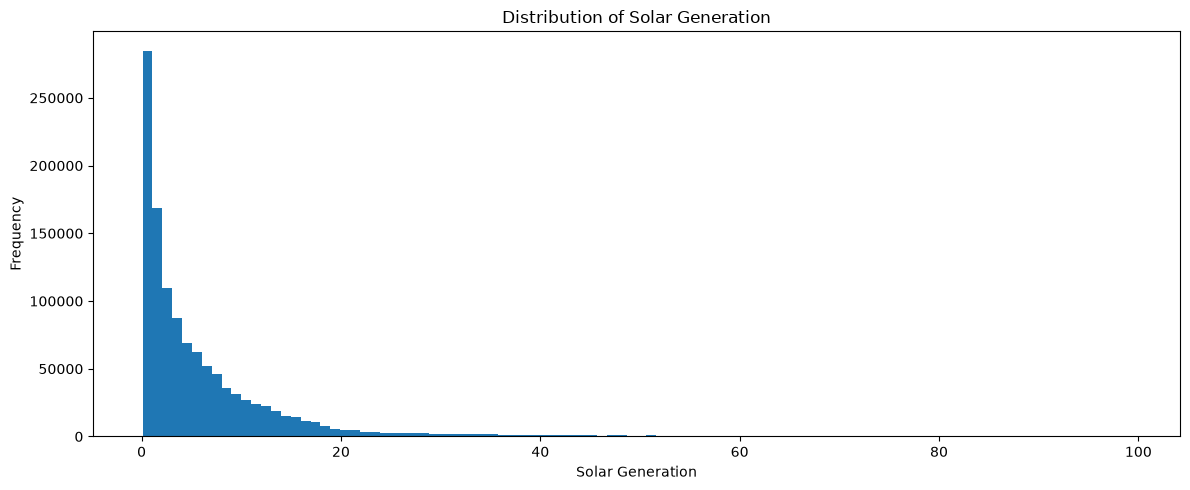

In [7]:
plt.figure(figsize=(12, 5))

plt.hist(
    ml_data[target],
    bins=100
)

plt.title("Distribution of Solar Generation")
plt.xlabel("Solar Generation")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [8]:
site_generation = (
    ml_data
    .groupby("SiteKey")["SolarGeneration"]
    .agg(
        mean="mean",
        median="median",
        max="max"
    )
    .sort_values("mean", ascending=False)
)

display(site_generation)

,mean,median,max
SiteKey,,,
11,36.4294,31.4688,92.7500
27,32.2267,26.4062,99.2188
25,28.7225,23.0000,80.2500
19,15.1131,12.2656,42.2188
18,12.8793,10.5625,35.3125
6,10.9167,9.2500,28.7344
8,10.2235,8.4219,26.9688
1,8.9364,7.8780,21.7780
41,8.5722,8.0625,21.9375


In [9]:
deployment_features = [
    "CampusKey",
    "SiteKey",

    "AirTemperature",
    "ApparentTemperature",
    "DewPointTemperature",
    "RelativeHumidity",
    "WindSpeed",

    "WindDirection_sin",
    "WindDirection_cos",

    "Hour_sin",
    "Hour_cos",

    "DayOfYear_sin",
    "DayOfYear_cos",

    "DayOfWeek",
    "Month",
    "IsWeekend"
]

target = "SolarGeneration"

print("Deployment features:")
for feature in deployment_features:
    print(" -", feature)

print("\nTarget:")
print(" -", target)

Deployment features:
 - CampusKey
 - SiteKey
 - AirTemperature
 - ApparentTemperature
 - DewPointTemperature
 - RelativeHumidity
 - WindSpeed
 - WindDirection_sin
 - WindDirection_cos
 - Hour_sin
 - Hour_cos
 - DayOfYear_sin
 - DayOfYear_cos
 - DayOfWeek
 - Month
 - IsWeekend

Target:
 - SolarGeneration


In [10]:
feature_check = ml_data[
    deployment_features + [target]
].isna().sum()

display(
    feature_check
    .to_frame("Missing_Count")
)

,Missing_Count
CampusKey,0
SiteKey,0
AirTemperature,0
ApparentTemperature,0
DewPointTemperature,0
RelativeHumidity,0
WindSpeed,0
WindDirection_sin,0
WindDirection_cos,0
Hour_sin,0


In [11]:
ml_data = ml_data.sort_values(
    "Timestamp"
).reset_index(drop=True)

print(
    "Sorted chronologically:",
    ml_data["Timestamp"].is_monotonic_increasing
)

Sorted chronologically: True


In [12]:
X = ml_data[deployment_features].copy()

y = ml_data[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1181498, 16)
y shape: (1181498,)


In [13]:
split_index = int(
    len(ml_data) * 0.80
)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print(
    "Training rows:",
    f"{len(X_train):,}"
)

print(
    "Testing rows:",
    f"{len(X_test):,}"
)

Training rows: 945,198
Testing rows: 236,300


In [14]:
print("Training period:")
print(
    X_train.index.min(),
    "→",
    ml_data.iloc[split_index - 1]["Timestamp"]
)

print("\nTesting period:")
print(
    ml_data.iloc[split_index]["Timestamp"],
    "→",
    ml_data["Timestamp"].max()
)

Training period:
0 → 2021-12-21 18:00:00

Testing period:
2021-12-21 18:00:00 → 2022-04-23 17:45:00


In [15]:
baseline = DummyRegressor(
    strategy="mean"
)

baseline.fit(
    X_train,
    y_train
)

baseline_prediction = baseline.predict(
    X_test
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_prediction
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_prediction
)

print("BASELINE MODEL")
print("=" * 50)

print(
    f"MAE  : {baseline_mae:.4f}"
)

print(
    f"RMSE : {baseline_rmse:.4f}"
)

print(
    f"R²   : {baseline_r2:.4f}"
)

BASELINE MODEL
MAE  : 6.9220
RMSE : 12.3342
R²   : -0.0077


In [16]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Training Random Forest...


Random Forest training completed.


In [17]:
rf_prediction = rf_model.predict(
    X_test
)

rf_mae = mean_absolute_error(
    y_test,
    rf_prediction
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_prediction
    )
)

rf_r2 = r2_score(
    y_test,
    rf_prediction
)

print("RANDOM FOREST")
print("=" * 50)

print(
    f"MAE  : {rf_mae:.4f}"
)

print(
    f"RMSE : {rf_rmse:.4f}"
)

print(
    f"R²   : {rf_r2:.4f}"
)

RANDOM FOREST
MAE  : 2.3534
RMSE : 4.8842
R²   : 0.8420


In [18]:
model_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Random Forest"
    ],

    "MAE": [
        baseline_mae,
        rf_mae
    ],

    "RMSE": [
        baseline_rmse,
        rf_rmse
    ],

    "R2": [
        baseline_r2,
        rf_r2
    ]
})

display(
    model_results.sort_values(
        "RMSE"
    )
)

,Model,MAE,RMSE,R2
1,Random Forest,2.3534,4.8842,0.8420
0,Baseline,6.9220,12.3342,-0.0077


In [19]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_prediction
})

display(
    comparison.head(20)
)

,Actual,Predicted
0,3.1875,2.4093
1,20.0000,15.3541
2,4.3047,3.9548
3,4.8906,3.9548
4,11.1250,6.9468
5,2.5977,2.0005
6,6.2813,4.2812
7,39.6250,37.4509
8,17.3125,15.3494
9,44.0000,39.1106


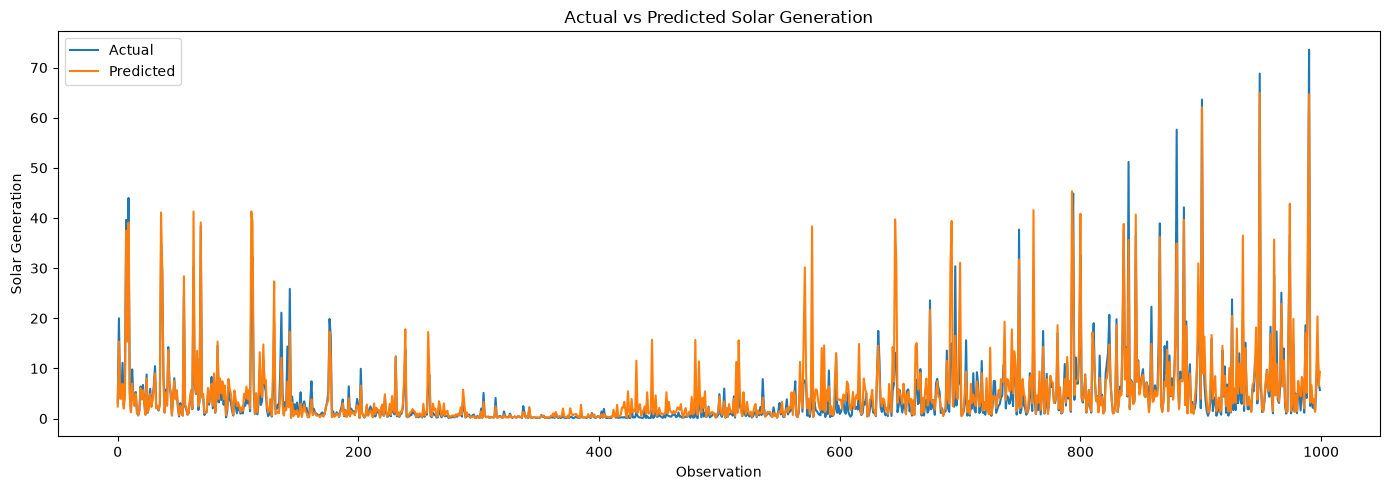

In [20]:
sample_size = min(
    1000,
    len(comparison)
)

sample = comparison.iloc[
    :sample_size
]

plt.figure(figsize=(14, 5))

plt.plot(
    sample["Actual"].values,
    label="Actual"
)

plt.plot(
    sample["Predicted"].values,
    label="Predicted"
)

plt.title(
    "Actual vs Predicted Solar Generation"
)

plt.xlabel("Observation")
plt.ylabel("Solar Generation")

plt.legend()

plt.tight_layout()
plt.show()

In [21]:
feature_importance = pd.DataFrame({
    "Feature": deployment_features,
    "Importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

display(feature_importance)

,Feature,Importance
1,SiteKey,0.6219
5,RelativeHumidity,0.1099
10,Hour_cos,0.0784
12,DayOfYear_cos,0.0477
11,DayOfYear_sin,0.0250
9,Hour_sin,0.0179
2,AirTemperature,0.0142
6,WindSpeed,0.0142
3,ApparentTemperature,0.0137
4,DewPointTemperature,0.0129


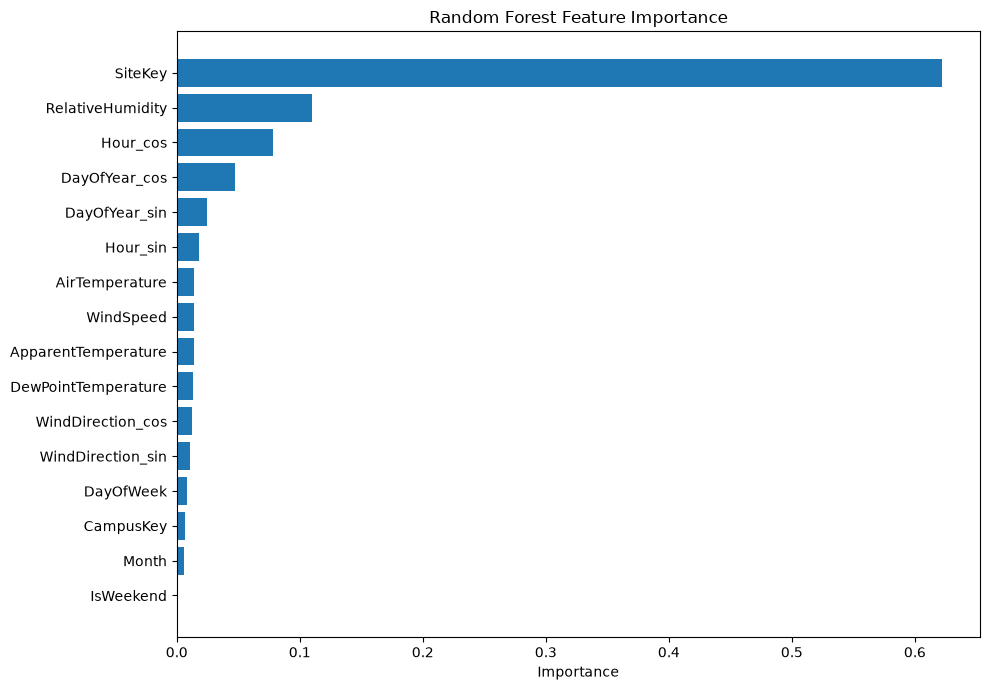

In [22]:
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel("Importance")

plt.tight_layout()
plt.show()

#### Model Diagnostics

The Random Forest model substantially outperformed the baseline model.

Before using the model for underperformance detection, we evaluate:

1. Actual vs predicted generation
2. Prediction error distribution
3. Residual behavior
4. Site-level performance
5. Feature importance

This ensures that the model is not performing well only because of aggregate behavior while failing for individual solar sites.

In [23]:
test_results = ml_data.iloc[
    split_index:
].copy()

test_results["ActualGeneration"] = y_test.values

test_results["ExpectedGeneration"] = rf_prediction

test_results["Residual"] = (
    test_results["ActualGeneration"]
    - test_results["ExpectedGeneration"]
)

test_results["AbsoluteError"] = (
    test_results["Residual"].abs()
)

display(
    test_results[
        [
            "SiteKey",
            "Timestamp",
            "ActualGeneration",
            "ExpectedGeneration",
            "Residual",
            "AbsoluteError"
        ]
    ].head(20)
)

,SiteKey,Timestamp,ActualGeneration,ExpectedGeneration,Residual,AbsoluteError
945198,31,2021-12-21 18:00:00,3.1875,2.4093,0.7782,0.7782
945199,19,2021-12-21 18:00:00,20.0000,15.3541,4.6459,4.6459
945200,37,2021-12-21 18:00:00,4.3047,3.9548,0.3499,0.3499
945201,36,2021-12-21 18:00:00,4.8906,3.9548,0.9358,0.9358
945202,41,2021-12-21 18:00:00,11.1250,6.9468,4.1782,4.1782
945203,35,2021-12-21 18:00:00,2.5977,2.0005,0.5972,0.5972
945204,3,2021-12-21 18:00:00,6.2813,4.2812,2.0001,2.0001
945205,27,2021-12-21 18:00:00,39.6250,37.4509,2.1741,2.1741
945206,19,2021-12-21 18:15:00,17.3125,15.3494,1.9631,1.9631
945207,11,2021-12-21 18:15:00,44.0000,39.1106,4.8894,4.8894


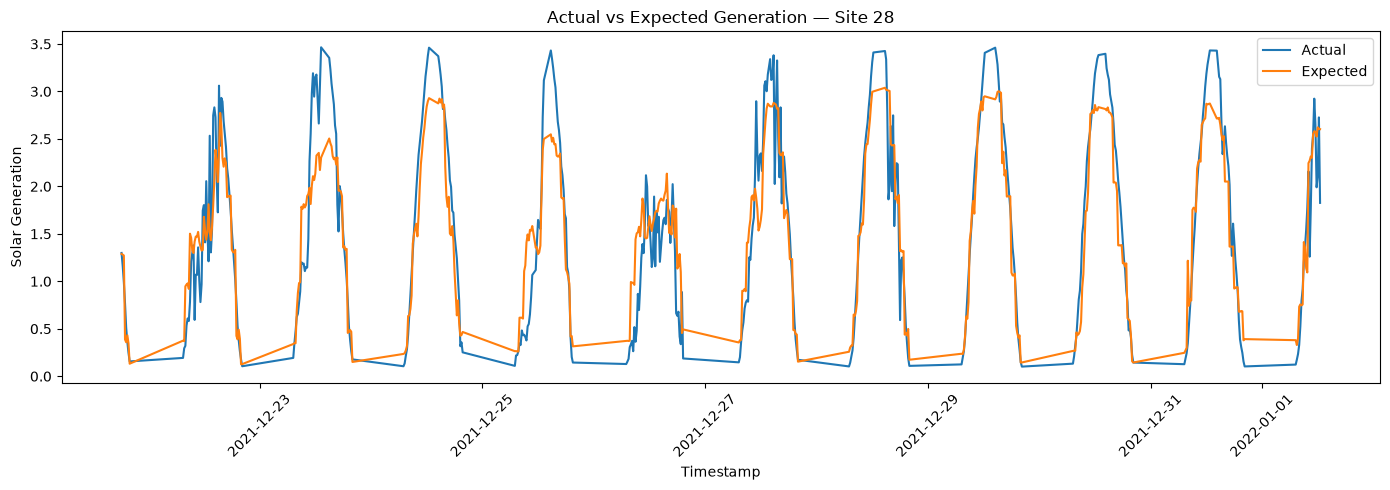

In [24]:
# Select a site with a substantial number of test observations
selected_site = 28

site_plot = test_results[
    test_results["SiteKey"] == selected_site
].sort_values("Timestamp")

# Plot a manageable sample
site_plot_sample = site_plot.head(500)

plt.figure(figsize=(14, 5))

plt.plot(
    site_plot_sample["Timestamp"],
    site_plot_sample["ActualGeneration"],
    label="Actual"
)

plt.plot(
    site_plot_sample["Timestamp"],
    site_plot_sample["ExpectedGeneration"],
    label="Expected"
)

plt.title(
    f"Actual vs Expected Generation — Site {selected_site}"
)

plt.xlabel("Timestamp")
plt.ylabel("Solar Generation")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

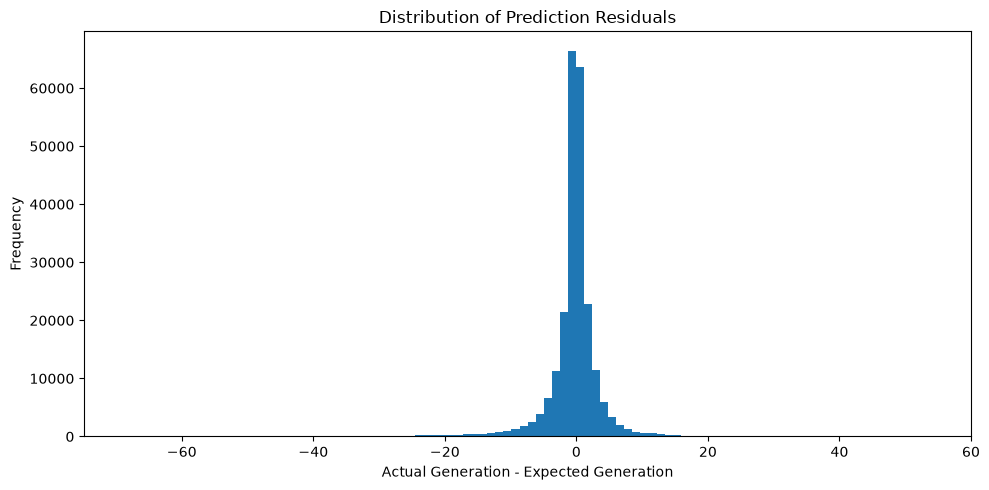

In [25]:
plt.figure(figsize=(10, 5))

plt.hist(
    test_results["Residual"],
    bins=100
)

plt.title(
    "Distribution of Prediction Residuals"
)

plt.xlabel(
    "Actual Generation - Expected Generation"
)

plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [26]:
residual_stats = test_results["Residual"].describe()

display(residual_stats)

count   236,300.0000
mean         -0.4703
std           4.8615
min         -68.7013
25%          -1.1457
50%          -0.0901
75%           0.8913
max          53.8810
Name: Residual, dtype: float64

In [27]:
print(
    "Mean residual:",
    round(test_results["Residual"].mean(), 4)
)

print(
    "Median residual:",
    round(test_results["Residual"].median(), 4)
)

Mean residual: -0.4703
Median residual: -0.0901


In [28]:
test_results["DeviationPercentage"] = (
    (
        test_results["ActualGeneration"]
        - test_results["ExpectedGeneration"]
    )
    /
    test_results["ExpectedGeneration"]
    * 100
)

In [29]:
display(
    test_results[
        [
            "SiteKey",
            "Timestamp",
            "ActualGeneration",
            "ExpectedGeneration",
            "DeviationPercentage"
        ]
    ].head(20)
)

,SiteKey,Timestamp,ActualGeneration,ExpectedGeneration,DeviationPercentage
945198,31,2021-12-21 18:00:00,3.1875,2.4093,32.2984
945199,19,2021-12-21 18:00:00,20.0000,15.3541,30.2586
945200,37,2021-12-21 18:00:00,4.3047,3.9548,8.8475
945201,36,2021-12-21 18:00:00,4.8906,3.9548,23.6624
945202,41,2021-12-21 18:00:00,11.1250,6.9468,60.1463
945203,35,2021-12-21 18:00:00,2.5977,2.0005,29.8549
945204,3,2021-12-21 18:00:00,6.2813,4.2812,46.7165
945205,27,2021-12-21 18:00:00,39.6250,37.4509,5.8052
945206,19,2021-12-21 18:15:00,17.3125,15.3494,12.7894
945207,11,2021-12-21 18:15:00,44.0000,39.1106,12.5015


In [30]:
MIN_EXPECTED_GENERATION = 0.5

test_results["DeviationPercentage"] = np.where(
    test_results["ExpectedGeneration"]
    >= MIN_EXPECTED_GENERATION,

    (
        (
            test_results["ActualGeneration"]
            - test_results["ExpectedGeneration"]
        )
        /
        test_results["ExpectedGeneration"]
        * 100
    ),

    np.nan
)

In [31]:
valid_deviation = test_results[
    "DeviationPercentage"
].dropna()

print(
    valid_deviation.describe()
)

count   221,270.0000
mean         -4.2353
std          49.3828
min         -99.2133
25%         -36.6821
50%          -3.2903
75%          19.1255
max       2,208.7729
Name: DeviationPercentage, dtype: float64


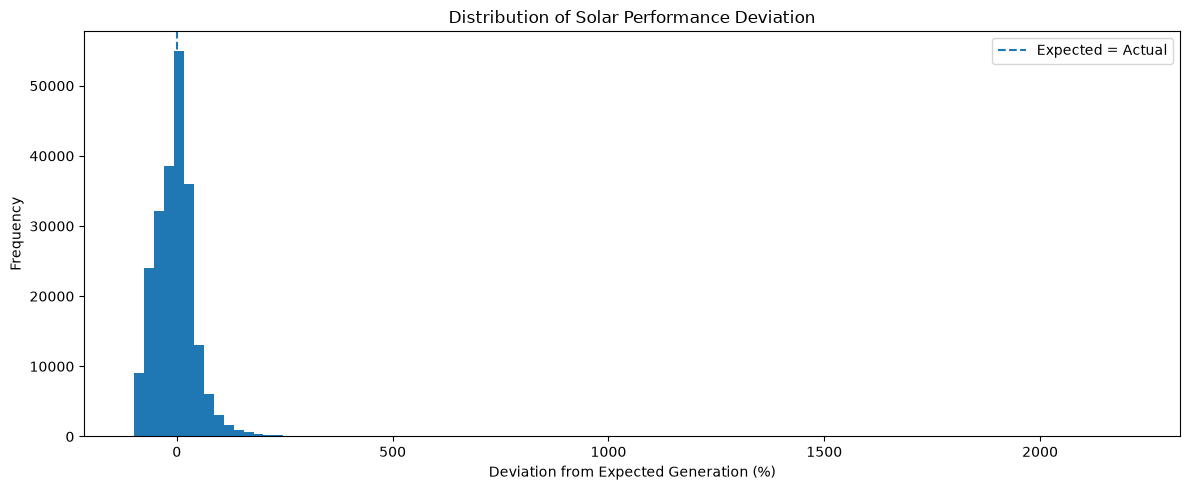

In [32]:
plt.figure(figsize=(12, 5))

plt.hist(
    valid_deviation,
    bins=100
)

plt.axvline(
    0,
    linestyle="--",
    label="Expected = Actual"
)

plt.title(
    "Distribution of Solar Performance Deviation"
)

plt.xlabel(
    "Deviation from Expected Generation (%)"
)

plt.ylabel(
    "Frequency"
)

plt.legend()

plt.tight_layout()
plt.show()

In [33]:
site_performance = (
    test_results
    .groupby("SiteKey")
    .agg(
        Observations=("ActualGeneration", "size"),

        MAE=(
            "AbsoluteError",
            "mean"
        ),

        ActualMean=(
            "ActualGeneration",
            "mean"
        ),

        ExpectedMean=(
            "ExpectedGeneration",
            "mean"
        )
    )
)

site_performance["MAE_Percent_of_Actual"] = (
    site_performance["MAE"]
    /
    site_performance["ActualMean"]
    * 100
)

display(
    site_performance
    .sort_values(
        "MAE_Percent_of_Actual",
        ascending=False
    )
)

,Observations,MAE,ActualMean,ExpectedMean,MAE_Percent_of_Actual
SiteKey,,,,,
24,5871,3.0261,5.5007,7.7060,55.0123
13,5466,1.9388,4.3858,5.6892,44.2065
27,6562,12.4984,29.1275,39.8732,42.9094
41,5746,3.5846,9.9729,8.7559,35.9432
42,5768,0.9206,2.8768,3.0166,32.0003
30,5704,1.0093,3.2182,3.4305,31.3617
39,5626,0.8604,2.8033,3.0271,30.6932
21,5729,1.0005,3.2663,3.5075,30.6328
34,5629,0.5543,1.8154,2.0224,30.5355


In [34]:
feature_importance = pd.DataFrame({
    "Feature": deployment_features,
    "Importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(feature_importance)

,Feature,Importance
0,SiteKey,0.6219
1,RelativeHumidity,0.1099
2,Hour_cos,0.0784
3,DayOfYear_cos,0.0477
4,DayOfYear_sin,0.0250
5,Hour_sin,0.0179
6,AirTemperature,0.0142
7,WindSpeed,0.0142
8,ApparentTemperature,0.0137
9,DewPointTemperature,0.0129


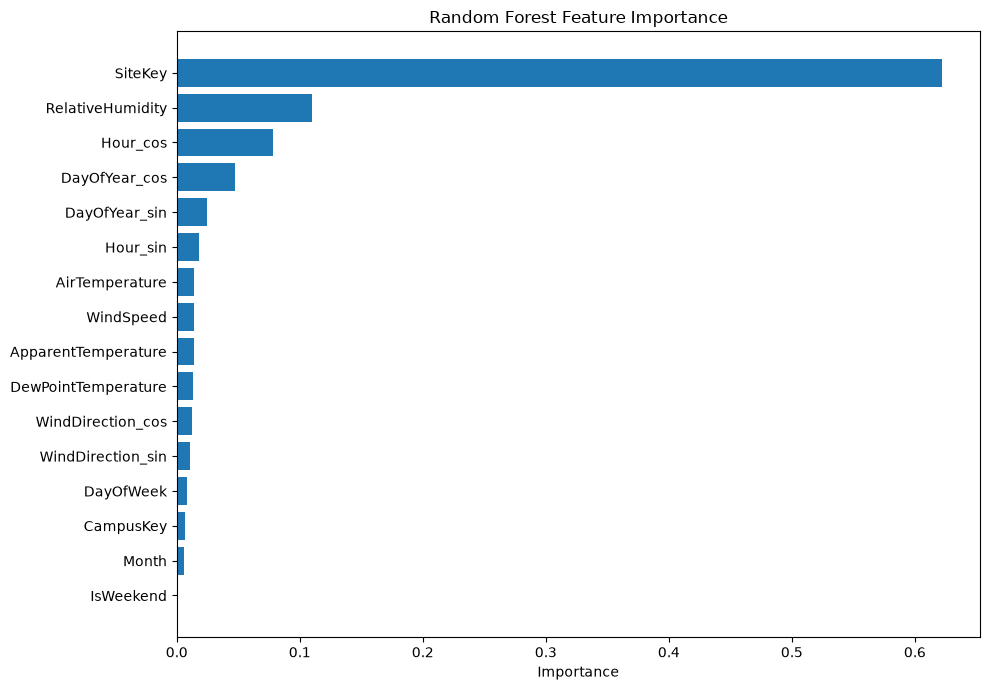

In [35]:
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel("Importance")

plt.tight_layout()
plt.show()

In [36]:
test_results["Residual"].describe()

count   236,300.0000
mean         -0.4703
std           4.8615
min         -68.7013
25%          -1.1457
50%          -0.0901
75%           0.8913
max          53.8810
Name: Residual, dtype: float64

In [37]:
valid_deviation.describe()

count   221,270.0000
mean         -4.2353
std          49.3828
min         -99.2133
25%         -36.6821
50%          -3.2903
75%          19.1255
max       2,208.7729
Name: DeviationPercentage, dtype: float64

#### Performance Deviation Analysis

The regression model predicts expected solar generation.

To identify potential underperformance, actual generation is compared
with model-estimated expected generation.

Percentage deviation is useful for comparing sites with different
generation scales. However, the metric becomes unstable when expected
generation is very close to zero.

Therefore, observations with very low expected generation are excluded
from percentage-based underperformance analysis.

Raw residuals remain available for model diagnostics.

In [38]:
expected_distribution = (
    test_results["ExpectedGeneration"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

display(expected_distribution)

count   236,300.0000
mean          8.3295
std          12.5870
min           0.1204
1%            0.2461
5%            0.4332
10%           0.6739
25%           1.6035
50%           4.4322
75%           9.4264
90%          16.8883
95%          30.8789
99%          70.9494
max          88.5615
Name: ExpectedGeneration, dtype: float64

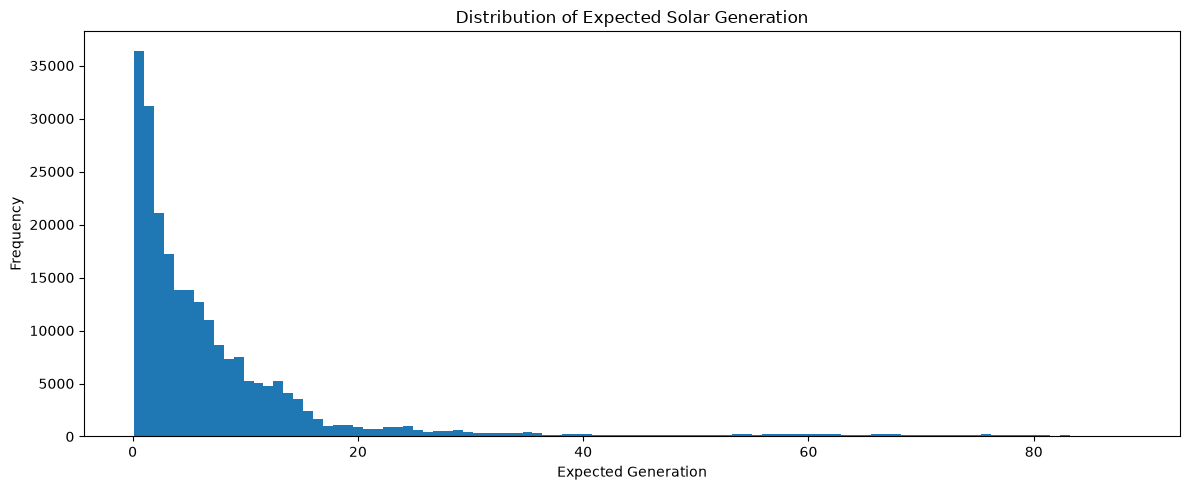

In [39]:
plt.figure(figsize=(12, 5))

plt.hist(
    test_results["ExpectedGeneration"],
    bins=100
)

plt.title(
    "Distribution of Expected Solar Generation"
)

plt.xlabel("Expected Generation")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [40]:
test_results["ExpectedBin"] = pd.qcut(
    test_results["ExpectedGeneration"],
    q=10,
    duplicates="drop"
)

deviation_by_expected = (
    test_results
    .groupby("ExpectedBin", observed=True)
    ["DeviationPercentage"]
    .agg(
        count="count",
        median="median",
        mean="mean",
        p10=lambda x: x.quantile(0.10),
        p90=lambda x: x.quantile(0.90)
    )
)

display(deviation_by_expected)

,count,median,mean,p10,p90
ExpectedBin,,,,,
"(0.119, 0.674]",8600,-22.0947,-5.0564,-72.0108,72.8176
"(0.674, 1.299]",23630,-12.6608,-1.4745,-70.8340,72.5939
"(1.299, 2.029]",23630,-7.7495,-5.7195,-68.5656,53.0017
"(2.029, 3.034]",23630,-9.5020,-6.4919,-67.2130,54.6568
"(3.034, 4.432]",23630,-5.6549,-4.9013,-64.1607,51.9382
"(4.432, 5.975]",23631,-2.6140,-4.5850,-58.6445,41.8809
"(5.975, 8.029]",23629,0.2460,-4.0070,-55.4515,37.8272
"(8.029, 11.236]",23630,1.3676,-2.7273,-53.4557,38.9901
"(11.236, 16.888]",23630,5.1253,-1.2064,-50.9919,36.4534


In [41]:
PERFORMANCE_FLOOR = 1.0

test_results["PerformanceDeviation"] = np.where(
    test_results["ExpectedGeneration"] >= PERFORMANCE_FLOOR,
    
    (
        (
            test_results["ActualGeneration"]
            - test_results["ExpectedGeneration"]
        )
        /
        test_results["ExpectedGeneration"]
        * 100
    ),
    
    np.nan
)

In [42]:
display(
    test_results[
        [
            "SiteKey",
            "Timestamp",
            "ActualGeneration",
            "ExpectedGeneration",
            "PerformanceDeviation"
        ]
    ].head(20)
)

,SiteKey,Timestamp,ActualGeneration,ExpectedGeneration,PerformanceDeviation
945198,31,2021-12-21 18:00:00,3.1875,2.4093,32.2984
945199,19,2021-12-21 18:00:00,20.0000,15.3541,30.2586
945200,37,2021-12-21 18:00:00,4.3047,3.9548,8.8475
945201,36,2021-12-21 18:00:00,4.8906,3.9548,23.6624
945202,41,2021-12-21 18:00:00,11.1250,6.9468,60.1463
945203,35,2021-12-21 18:00:00,2.5977,2.0005,29.8549
945204,3,2021-12-21 18:00:00,6.2813,4.2812,46.7165
945205,27,2021-12-21 18:00:00,39.6250,37.4509,5.8052
945206,19,2021-12-21 18:15:00,17.3125,15.3494,12.7894
945207,11,2021-12-21 18:15:00,44.0000,39.1106,12.5015


In [43]:
site_model_summary = (
    test_results
    .groupby("SiteKey")
    .agg(
        Observations=("ActualGeneration", "size"),
        Actual_Mean=("ActualGeneration", "mean"),
        Expected_Mean=("ExpectedGeneration", "mean"),
        MAE=("AbsoluteError", "mean"),
        RMSE=(
            "Residual",
            lambda x: np.sqrt(np.mean(x ** 2))
        )
    )
)

site_model_summary["Bias"] = (
    site_model_summary["Actual_Mean"]
    - site_model_summary["Expected_Mean"]
)

display(
    site_model_summary.sort_values(
        "MAE",
        ascending=False
    )
)

,Observations,Actual_Mean,Expected_Mean,MAE,RMSE,Bias
SiteKey,,,,,,
27,6562,29.1275,39.8732,12.4984,17.1712,-10.7457
11,6149,41.4143,41.4950,9.8224,13.9427,-0.0807
25,5786,31.8802,33.4077,9.6826,13.0591,-1.5276
19,5937,16.9634,17.3833,4.8952,6.6106,-0.4199
18,6004,14.4210,15.3388,4.3323,5.7581,-0.9178
41,5746,9.9729,8.7559,3.5846,4.5809,1.2170
6,6004,12.8930,12.2520,3.0567,4.1630,0.6410
24,5871,5.5007,7.7060,3.0261,3.8651,-2.2053
8,5999,11.7372,11.5110,2.7953,4.0262,0.2262


In [44]:
display(
    site_model_summary.sort_values(
        "MAE",
        ascending=False
    )
)

,Observations,Actual_Mean,Expected_Mean,MAE,RMSE,Bias
SiteKey,,,,,,
27,6562,29.1275,39.8732,12.4984,17.1712,-10.7457
11,6149,41.4143,41.4950,9.8224,13.9427,-0.0807
25,5786,31.8802,33.4077,9.6826,13.0591,-1.5276
19,5937,16.9634,17.3833,4.8952,6.6106,-0.4199
18,6004,14.4210,15.3388,4.3323,5.7581,-0.9178
41,5746,9.9729,8.7559,3.5846,4.5809,1.2170
6,6004,12.8930,12.2520,3.0567,4.1630,0.6410
24,5871,5.5007,7.7060,3.0261,3.8651,-2.2053
8,5999,11.7372,11.5110,2.7953,4.0262,0.2262


In [45]:
expected_percentiles = (
    test_results["ExpectedGeneration"]
    .describe(
        percentiles=[
            0.05,
            0.10,
            0.15,
            0.20,
            0.25,
            0.30,
            0.40,
            0.50
        ]
    )
)

display(expected_percentiles)

count   236,300.0000
mean          8.3295
std          12.5870
min           0.1204
5%            0.4332
10%           0.6739
15%           0.9815
20%           1.2986
25%           1.6035
30%           2.0287
40%           3.0335
50%           4.4322
max          88.5615
Name: ExpectedGeneration, dtype: float64

In [46]:
production_candidates = [
    0.5,
    1.0,
    2.0,
    3.0,
    5.0
]

for threshold in production_candidates:

    count = (
        test_results["ExpectedGeneration"]
        >= threshold
    ).sum()

    percentage = (
        count /
        len(test_results)
        * 100
    )

    print(
        f"Expected >= {threshold:>4}: "
        f"{count:,} observations "
        f"({percentage:.2f}%)"
    )

Expected >=  0.5: 221,270 observations (93.64%)
Expected >=  1.0: 200,091 observations (84.68%)
Expected >=  2.0: 166,064 observations (70.28%)
Expected >=  3.0: 142,501 observations (60.31%)
Expected >=  5.0: 109,271 observations (46.24%)


In [47]:
PERFORMANCE_FLOOR = 1.0

test_results["PerformanceDeviation"] = np.where(
    (
        test_results["ExpectedGeneration"]
        >= PERFORMANCE_FLOOR
    )
    &
    (
        test_results["IsProductionPeriod"] == 1
    ),

    (
        (
            test_results["ActualGeneration"]
            -
            test_results["ExpectedGeneration"]
        )
        /
        test_results["ExpectedGeneration"]
        * 100
    ),

    np.nan
)

In [48]:
display(
    test_results[
        [
            "SiteKey",
            "Timestamp",
            "ActualGeneration",
            "ExpectedGeneration",
            "PerformanceDeviation"
        ]
    ].head(20)
)

,SiteKey,Timestamp,ActualGeneration,ExpectedGeneration,PerformanceDeviation
945198,31,2021-12-21 18:00:00,3.1875,2.4093,32.2984
945199,19,2021-12-21 18:00:00,20.0000,15.3541,30.2586
945200,37,2021-12-21 18:00:00,4.3047,3.9548,8.8475
945201,36,2021-12-21 18:00:00,4.8906,3.9548,23.6624
945202,41,2021-12-21 18:00:00,11.1250,6.9468,60.1463
945203,35,2021-12-21 18:00:00,2.5977,2.0005,29.8549
945204,3,2021-12-21 18:00:00,6.2813,4.2812,46.7165
945205,27,2021-12-21 18:00:00,39.6250,37.4509,5.8052
945206,19,2021-12-21 18:15:00,17.3125,15.3494,12.7894
945207,11,2021-12-21 18:15:00,44.0000,39.1106,12.5015


In [49]:
performance_values = (
    test_results["PerformanceDeviation"]
    .dropna()
)

print(
    performance_values.describe()
)

count   199,774.0000
mean         -4.3344
std          45.6133
min         -99.2133
25%         -34.5376
50%          -2.2124
75%          18.8278
max       2,208.7729
Name: PerformanceDeviation, dtype: float64


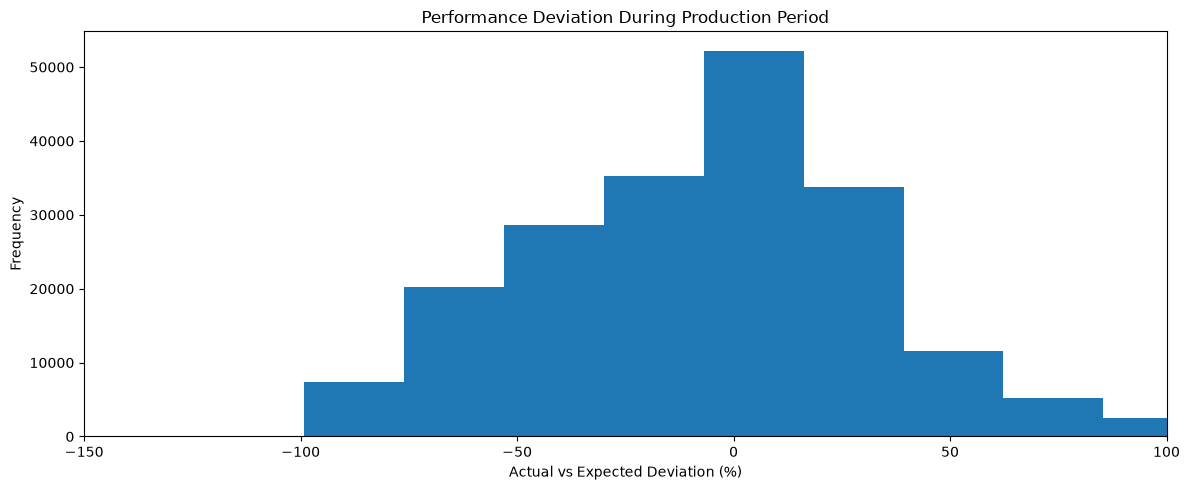

In [50]:
plt.figure(figsize=(12, 5))

plt.hist(
    performance_values,
    bins=100
)

plt.title(
    "Performance Deviation During Production Period"
)

plt.xlabel(
    "Actual vs Expected Deviation (%)"
)

plt.ylabel("Frequency")

plt.xlim(-150, 100)

plt.tight_layout()
plt.show()

In [51]:
performance_thresholds = {
    "1st_percentile": performance_values.quantile(0.01),
    "2nd_percentile": performance_values.quantile(0.02),
    "5th_percentile": performance_values.quantile(0.05),
    "10th_percentile": performance_values.quantile(0.10),
    "25th_percentile": performance_values.quantile(0.25)
}

for name, value in performance_thresholds.items():
    print(
        f"{name:<18}: {value:.2f}%"
    )

1st_percentile    : -87.61%
2nd_percentile    : -82.70%
5th_percentile    : -72.09%
10th_percentile   : -60.47%
25th_percentile   : -34.54%


#### Solar Performance & Underperformance Detection

The regression model estimates the expected generation for each
observation based on site, temporal, and meteorological conditions.

Underperformance is evaluated only during the observed production
period and when expected generation is sufficiently large for a
percentage comparison to be meaningful.

The performance deviation is:

    (Actual Generation - Expected Generation)
    ----------------------------------------- × 100
             Expected Generation

Large negative deviations indicate that the site produced
substantially less energy than expected.

In [52]:
PERFORMANCE_FLOOR = 1.0

test_results["PerformanceDeviation"] = np.where(
    (
        test_results["IsProductionPeriod"] == 1
    ) &
    (
        test_results["ExpectedGeneration"] >= PERFORMANCE_FLOOR
    ),

    (
        (
            test_results["ActualGeneration"]
            -
            test_results["ExpectedGeneration"]
        )
        /
        test_results["ExpectedGeneration"]
        * 100
    ),

    np.nan
)

In [53]:
test_results["PerformanceRatio"] = np.where(
    (
        test_results["IsProductionPeriod"] == 1
    ) &
    (
        test_results["ExpectedGeneration"] >= PERFORMANCE_FLOOR
    ),

    (
        test_results["ActualGeneration"]
        /
        test_results["ExpectedGeneration"]
    ),

    np.nan
)

In [54]:
performance_values = (
    test_results["PerformanceDeviation"]
    .dropna()
)

print(
    performance_values.describe(
        percentiles=[
            0.01,
            0.02,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

count   199,774.0000
mean         -4.3344
std          45.6133
min         -99.2133
1%          -87.6134
2%          -82.7044
5%          -72.0937
10%         -60.4714
25%         -34.5376
50%          -2.2124
75%          18.8278
90%          42.5299
95%          64.9634
99%         126.1860
max       2,208.7729
Name: PerformanceDeviation, dtype: float64


In [55]:
warning_threshold = performance_values.quantile(0.10)
critical_threshold = performance_values.quantile(0.05)

print(
    f"Warning threshold  : {warning_threshold:.2f}%"
)

print(
    f"Critical threshold : {critical_threshold:.2f}%"
)

Warning threshold  : -60.47%
Critical threshold : -72.09%


In [56]:
test_results["PerformanceStatus"] = np.select(

    [
        test_results["PerformanceDeviation"].isna(),

        test_results["PerformanceDeviation"]
        <= critical_threshold,

        test_results["PerformanceDeviation"]
        <= warning_threshold
    ],

    [
        "Not Applicable",
        "Critical",
        "Warning"
    ],

    default="Normal"
)

In [57]:
display(
    test_results[
        "PerformanceStatus"
    ].value_counts()
    .to_frame("Observations")
)

,Observations
PerformanceStatus,
Normal,179796
Not Applicable,36526
Warning,9989
Critical,9989


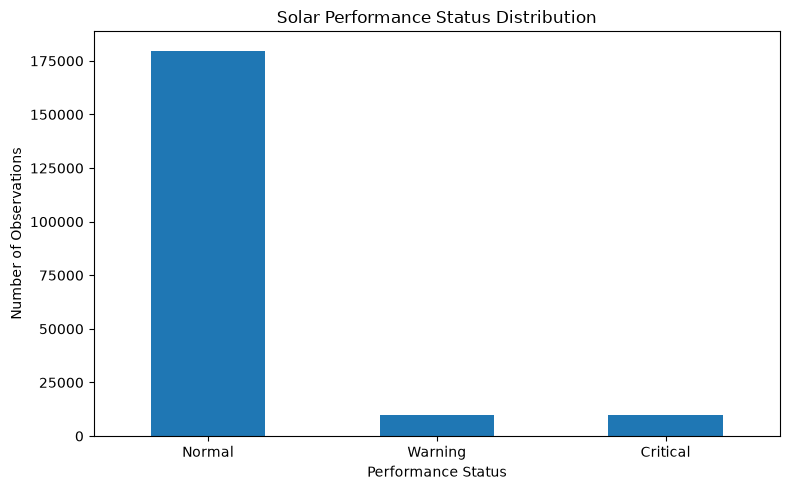

In [58]:
status_counts = (
    test_results[
        test_results["PerformanceStatus"]
        != "Not Applicable"
    ]["PerformanceStatus"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

status_counts.plot(
    kind="bar"
)

plt.title(
    "Solar Performance Status Distribution"
)

plt.xlabel("Performance Status")
plt.ylabel("Number of Observations")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [59]:
worst_observations = (
    test_results[
        test_results["PerformanceStatus"]
        == "Critical"
    ]
    .sort_values(
        "PerformanceDeviation"
    )
)

display(
    worst_observations[
        [
            "SiteKey",
            "Timestamp",
            "ActualGeneration",
            "ExpectedGeneration",
            "PerformanceDeviation",
            "PerformanceRatio"
        ]
    ].head(20)
)

,SiteKey,Timestamp,ActualGeneration,ExpectedGeneration,PerformanceDeviation,PerformanceRatio
1022116,11,2022-01-27 19:45:00,0.1250,15.8885,-99.2133,0.0079
1144797,27,2022-04-02 08:00:00,0.1250,14.0124,-99.1079,0.0089
1023435,25,2022-01-28 16:00:00,0.1250,13.4720,-99.0721,0.0093
992623,8,2022-01-13 17:00:00,0.1563,14.5310,-98.9244,0.0108
992673,11,2022-01-13 17:15:00,0.3125,28.3893,-98.8992,0.0110
992630,11,2022-01-13 17:00:00,0.6250,54.8446,-98.8604,0.0114
1022441,11,2022-01-28 08:45:00,0.1250,10.3376,-98.7908,0.0121
968553,25,2022-01-02 07:00:00,0.1875,14.4022,-98.6981,0.0130
1023509,11,2022-01-28 16:30:00,0.1875,14.2883,-98.6877,0.0131
1020092,11,2022-01-26 19:00:00,0.1250,9.0873,-98.6245,0.0138


In [60]:
test_results["EnergyLoss"] = np.where(

    test_results["PerformanceStatus"].isin(
        ["Warning", "Critical"]
    ),

    np.maximum(
        test_results["ExpectedGeneration"]
        -
        test_results["ActualGeneration"],
        0
    ),

    0
)

In [61]:
print(
    "Total potential energy loss:",
    round(
        test_results["EnergyLoss"].sum(),
        2
    )
)

Total potential energy loss: 108413.66


In [62]:
test_results["SevereUnderperformance"] = (
    test_results["PerformanceStatus"]
    == "Critical"
).astype(int)

In [63]:
test_results = test_results.sort_values(
    ["SiteKey", "Timestamp"]
).reset_index(drop=True)

In [64]:
test_results["UnderperformanceStreak"] = (
    test_results
    .groupby("SiteKey")["SevereUnderperformance"]
    .transform(
        lambda x:
        x.groupby(
            (x != x.shift()).cumsum()
        ).cumsum()
    )
)

In [65]:
test_results["PersistentUnderperformance"] = (
    test_results["UnderperformanceStreak"] >= 4
).astype(int)

In [66]:
display(
    test_results[
        test_results["PersistentUnderperformance"] == 1
    ][
        [
            "SiteKey",
            "Timestamp",
            "ActualGeneration",
            "ExpectedGeneration",
            "PerformanceDeviation",
            "PerformanceStatus",
            "UnderperformanceStreak"
        ]
    ].head(30)
)

,SiteKey,Timestamp,ActualGeneration,ExpectedGeneration,PerformanceDeviation,PerformanceStatus,UnderperformanceStreak
782,1,2022-01-05 10:00:00,0.1875,3.3410,-94.3879,Critical,4
783,1,2022-01-05 10:15:00,0.1250,4.1634,-96.9976,Critical,5
784,1,2022-01-05 10:30:00,0.1250,5.2017,-97.5969,Critical,6
785,1,2022-01-05 11:00:00,0.1875,5.1234,-96.3403,Critical,7
786,1,2022-01-05 11:15:00,0.3125,3.4517,-90.9464,Critical,8
787,1,2022-01-05 11:30:00,0.3750,3.2191,-88.3507,Critical,9
788,1,2022-01-05 11:45:00,0.3750,3.2191,-88.3507,Critical,10
789,1,2022-01-05 12:30:00,0.6875,3.8957,-82.3525,Critical,11
790,1,2022-01-05 12:45:00,0.4375,3.9392,-88.8937,Critical,12
798,1,2022-01-05 15:00:00,0.5000,1.9616,-74.5103,Critical,4


In [67]:
test_results["OperationalStatus"] = np.select(

    [
        test_results["PersistentUnderperformance"] == 1,

        test_results["PerformanceStatus"] == "Critical",

        test_results["PerformanceStatus"] == "Warning"
    ],

    [
        "Persistent Underperformance",
        "Critical Anomaly",
        "Warning"
    ],

    default="Normal"
)

In [68]:
site_operational_summary = (
    test_results
    .groupby("SiteKey")
    .agg(
        Observations=("ActualGeneration", "size"),

        ActualGeneration=(
            "ActualGeneration",
            "sum"
        ),

        ExpectedGeneration=(
            "ExpectedGeneration",
            "sum"
        ),

        AverageDeviation=(
            "PerformanceDeviation",
            "mean"
        ),

        AveragePerformanceRatio=(
            "PerformanceRatio",
            "mean"
        ),

        EnergyLoss=(
            "EnergyLoss",
            "sum"
        ),

        WarningCount=(
            "PerformanceStatus",
            lambda x: (x == "Warning").sum()
        ),

        CriticalCount=(
            "PerformanceStatus",
            lambda x: (x == "Critical").sum()
        ),

        PersistentCount=(
            "PersistentUnderperformance",
            "sum"
        )
    )
)

In [69]:
site_operational_summary["OverallPerformance"] = (
    site_operational_summary["ActualGeneration"]
    /
    site_operational_summary["ExpectedGeneration"]
    * 100
)

In [70]:
display(
    site_operational_summary
    .sort_values(
        "OverallPerformance"
    )
)

,Observations,ActualGeneration,ExpectedGeneration,AverageDeviation,AveragePerformanceRatio,EnergyLoss,WarningCount,CriticalCount,PersistentCount,OverallPerformance
SiteKey,,,,,,,,,,
24,5871,"32,294.7587","45,241.8919",-27.0337,0.7297,"5,428.0877",500,578,138,71.3824
27,6562,"191,134.7500","261,648.0700",-28.9695,0.7103,"26,241.3852",565,766,169,73.0503
13,5466,"23,972.6691","31,097.3355",-22.7734,0.7723,"3,585.6897",390,518,110,77.0891
34,5629,"10,218.9526","11,384.0951",-10.5274,0.8947,607.9164,232,207,34,89.7652
16,5277,"7,676.4932","8,538.7681",-10.3003,0.8970,416.0108,189,159,12,89.9016
37,5806,"23,248.9311","25,198.0426",-8.6362,0.9136,"1,239.4048",254,210,36,92.2648
32,5700,"15,486.5361","16,780.7886",-9.8218,0.9018,725.0580,219,170,26,92.2873
28,5425,"7,226.7854","7,828.6196",-7.9172,0.9208,261.5097,151,85,13,92.3124
39,5626,"15,771.4514","17,030.4172",-9.2034,0.9080,932.7677,254,238,42,92.6075


In [71]:
test_results["PerformanceStatus"].value_counts()

PerformanceStatus
Normal            179796
Not Applicable     36526
Warning             9989
Critical            9989
Name: count, dtype: int64

In [72]:
worst_observations.head(20)

,CampusKey,SiteKey,Timestamp,SolarGeneration,Hour,IsProductionPeriod,GenerationWasMissing,Minute,Day,Month,Year,DayOfWeek,DayOfYear,IsWeekend,Hour_sin,Hour_cos,DayOfYear_sin,DayOfYear_cos,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection,ApparentTemperature_WasMissing,AirTemperature_WasMissing,DewPointTemperature_WasMissing,RelativeHumidity_WasMissing,WindSpeed_WasMissing,WindDirection_WasMissing,WindDirection_sin,WindDirection_cos,AirTemperature_Outlier,ApparentTemperature_Outlier,DewPointTemperature_Outlier,WindSpeed_Outlier,WeatherAvailable,Generation_1HourAgo,PreviousGeneration,RollingGeneration_1Hour,ActualGeneration,ExpectedGeneration,Residual,AbsoluteError,DeviationPercentage,ExpectedBin,PerformanceDeviation,PerformanceRatio,PerformanceStatus
1022116,3,11,2022-01-27 19:45:00,0.1250,19,1,0,45,27,1,2022,3,27,0,-0.9659,0.2588,0.4479,0.8941,29.6000,29.6500,17.1000,46.0000,19.5800,177.8000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0384,-0.9993,0.0000,0.0000,0.0000,0.0000,1,12.1250,1.0000,6.2812,0.1250,15.8885,-15.7635,15.7635,-99.2133,"(11.236, 16.888]",-99.2133,0.0079,Critical
1144797,1,27,2022-04-02 08:00:00,0.1250,8,1,0,0,2,4,2022,5,92,1,0.8660,-0.5000,0.9999,-0.0118,12.6000,14.5000,11.7000,83.0000,6.7200,244.1665,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,-0.9001,-0.4358,0.0000,0.0000,0.0000,0.0000,1,1.3750,0.1250,0.5312,0.1250,14.0124,-13.8874,13.8874,-99.1079,"(11.236, 16.888]",-99.1079,0.0089,Critical
1023435,1,25,2022-01-28 16:00:00,0.1250,16,1,0,0,28,1,2022,4,28,0,-0.8660,-0.5000,0.4633,0.8862,22.7000,21.0000,21.0000,100.0000,15.9000,207.0335,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,-0.4545,-0.8907,0.0000,0.0000,1.0000,0.0000,1,0.4375,0.5625,0.5000,0.1250,13.4720,-13.3470,13.3470,-99.0721,"(11.236, 16.888]",-99.0721,0.0093,Critical
992623,3,8,2022-01-13 17:00:00,0.1563,17,1,0,0,13,1,2022,3,13,0,-0.9659,-0.2588,0.2218,0.9751,25.8000,29.6000,12.5000,35.0000,18.5700,197.8335,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,-0.3063,-0.9520,0.0000,0.0000,0.0000,0.0000,1,15.1250,0.7344,7.0117,0.1563,14.5310,-14.3747,14.3747,-98.9244,"(11.236, 16.888]",-98.9244,0.0108,Critical
992673,3,11,2022-01-13 17:15:00,0.3125,17,1,0,15,13,1,2022,3,13,0,-0.9659,-0.2588,0.2218,0.9751,22.6000,24.5000,16.7000,61.0000,18.5700,197.8335,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,-0.3063,-0.9520,0.0000,0.0000,0.0000,0.0000,1,31.6875,0.6250,11.4687,0.3125,28.3893,-28.0768,28.0768,-98.8992,"(16.888, 88.562]",-98.8992,0.0110,Critical
992630,3,11,2022-01-13 17:00:00,0.6250,17,1,0,0,13,1,2022,3,13,0,-0.9659,-0.2588,0.2218,0.9751,25.8000,29.6000,12.5000,35.0000,18.5700,197.8335,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,-0.3063,-0.9520,0.0000,0.0000,0.0000,0.0000,1,51.5000,2.6250,24.1875,0.6250,54.8446,-54.2196,54.2196,-98.8604,"(16.888, 88.562]",-98.8604,0.0114,Critical
1022441,3,11,2022-01-28 08:45:00,0.1250,8,1,0,45,28,1,2022,4,28,0,0.8660,-0.5000,0.4633,0.8862,25.9500,23.2000,20.7000,86.0000,14.1400,149.8665,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.5020,-0.8649,0.0000,0.0000,1.0000,0.0000,1,2.0000,10.7500,5.8594,0.1250,10.3376,-10.2126,10.2126,-98.7908,"(8.029, 11.236]",-98.7908,0.0121,Critical
968553,1,25,2022-01-02 07:00:00,0.1875,7,1,0,0,2,1,2022,6,2,1,0.9659,-0.2588,0.0344,0.9994,20.2000,20.5000,12.7000,61.0000,7.5665,210.2335,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,-0.5035,-0.8640,0.0000,0.0000,0.0000,0.0000,1,4.1875,0.6875,2.5000,0.1875,14.4022,-14.2147,14.2147,-98.6981,"(11.236, 16.888]",-98.6981,0.0130,Critical
1023509,3,11,2022-01-28 16:30:00,0.1875,16,1,0,30,28,1,2022,4,28,0,-0.8660,-0.5000,0.4633,0.8862,20.7000,22.9000,19.5000,81.0000,18.6400,208.6665,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,-0.4797,-0.8774,0.0000,0.0000,0.0000,0.0000,1,9.9375,2.4375,5.8906,0.1875,14.2883,-14.1008,14.1008,-98.6877,"(11.236, 16.888]",-98.6877,0.0131,Critical
1020092,3,11,2022-01-26 19:00:00,0.1250,19,1,0,0,26,1,2022,2,26,0,-0.9659,0.2588,0.4325,0.9016,23.9000,23.5000,19.0000,76.0000,19.5800,177.8000,0.0000

In [73]:
display(
    site_operational_summary
    .sort_values("OverallPerformance")
)

,Observations,ActualGeneration,ExpectedGeneration,AverageDeviation,AveragePerformanceRatio,EnergyLoss,WarningCount,CriticalCount,PersistentCount,OverallPerformance
SiteKey,,,,,,,,,,
24,5871,"32,294.7587","45,241.8919",-27.0337,0.7297,"5,428.0877",500,578,138,71.3824
27,6562,"191,134.7500","261,648.0700",-28.9695,0.7103,"26,241.3852",565,766,169,73.0503
13,5466,"23,972.6691","31,097.3355",-22.7734,0.7723,"3,585.6897",390,518,110,77.0891
34,5629,"10,218.9526","11,384.0951",-10.5274,0.8947,607.9164,232,207,34,89.7652
16,5277,"7,676.4932","8,538.7681",-10.3003,0.8970,416.0108,189,159,12,89.9016
37,5806,"23,248.9311","25,198.0426",-8.6362,0.9136,"1,239.4048",254,210,36,92.2648
32,5700,"15,486.5361","16,780.7886",-9.8218,0.9018,725.0580,219,170,26,92.2873
28,5425,"7,226.7854","7,828.6196",-7.9172,0.9208,261.5097,151,85,13,92.3124
39,5626,"15,771.4514","17,030.4172",-9.2034,0.9080,932.7677,254,238,42,92.6075


#### Validation-Based Performance Threshold Calibration

The original training dataset is divided chronologically into:

- Training subset: 80%
- Validation subset: 20%

The validation subset is used to calibrate operational
underperformance thresholds.

The final test set remains completely untouched until final evaluation.

In [74]:
validation_split = int(len(X_train) * 0.80)

X_subtrain = X_train.iloc[:validation_split].copy()
X_validation = X_train.iloc[validation_split:].copy()

y_subtrain = y_train.iloc[:validation_split].copy()
y_validation = y_train.iloc[validation_split:].copy()

print("Sub-training rows:", f"{len(X_subtrain):,}")
print("Validation rows :", f"{len(X_validation):,}")

Sub-training rows: 756,158
Validation rows : 189,040


In [75]:
calibration_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("Training calibration model...")

calibration_model.fit(
    X_subtrain,
    y_subtrain
)

print("Calibration model trained.")

Training calibration model...
Calibration model trained.


In [76]:
validation_prediction = (
    calibration_model.predict(
        X_validation
    )
)

In [77]:
validation_results = ml_data.iloc[
    X_validation.index
].copy()

validation_results["ActualGeneration"] = (
    y_validation.values
)

validation_results["ExpectedGeneration"] = (
    validation_prediction
)

validation_results["Residual"] = (
    validation_results["ActualGeneration"]
    -
    validation_results["ExpectedGeneration"]
)

In [78]:
validation_results["PerformanceDeviation"] = np.where(
    (
        validation_results["IsProductionPeriod"] == 1
    )
    &
    (
        validation_results["ExpectedGeneration"] >= PERFORMANCE_FLOOR
    ),

    (
        (
            validation_results["ActualGeneration"]
            -
            validation_results["ExpectedGeneration"]
        )
        /
        validation_results["ExpectedGeneration"]
        * 100
    ),

    np.nan
)

In [79]:
validation_performance = (
    validation_results[
        "PerformanceDeviation"
    ].dropna()
)

print(
    validation_performance.describe(
        percentiles=[
            0.01,
            0.02,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

count   156,733.0000
mean          5.5744
std          54.5875
min         -99.6687
1%          -86.3828
2%          -80.8713
5%          -69.5747
10%         -57.4229
25%         -30.4429
50%           3.3228
75%          31.7556
90%          64.2317
95%          93.7129
99%         179.1105
max       1,590.2903
Name: PerformanceDeviation, dtype: float64


In [80]:
WARNING_THRESHOLD = (
    validation_performance.quantile(0.10)
)

CRITICAL_THRESHOLD = (
    validation_performance.quantile(0.05)
)

print(
    f"Warning threshold  : {WARNING_THRESHOLD:.2f}%"
)

print(
    f"Critical threshold : {CRITICAL_THRESHOLD:.2f}%"
)

Warning threshold  : -57.42%
Critical threshold : -69.57%


In [81]:
test_results["PerformanceStatus"] = np.select(

    [
        test_results["PerformanceDeviation"].isna(),

        test_results["PerformanceDeviation"]
        <= CRITICAL_THRESHOLD,

        test_results["PerformanceDeviation"]
        <= WARNING_THRESHOLD
    ],

    [
        "Not Applicable",
        "Critical",
        "Warning"
    ],

    default="Normal"
)

In [82]:
display(
    test_results[
        "PerformanceStatus"
    ].value_counts()
)

PerformanceStatus
Normal            176778
Not Applicable     36526
Critical           11899
Warning            11097
Name: count, dtype: int64

In [83]:
test_results["EnergyLoss"] = np.where(

    test_results["PerformanceStatus"].isin(
        ["Warning", "Critical"]
    ),

    np.maximum(
        test_results["ExpectedGeneration"]
        -
        test_results["ActualGeneration"],
        0
    ),

    0
)

In [84]:
test_results["SevereUnderperformance"] = (
    test_results["PerformanceStatus"]
    == "Critical"
).astype(int)

test_results = test_results.sort_values(
    ["SiteKey", "Timestamp"]
).reset_index(drop=True)

test_results["UnderperformanceStreak"] = (
    test_results
    .groupby("SiteKey")["SevereUnderperformance"]
    .transform(
        lambda x:
        x.groupby(
            (x != x.shift()).cumsum()
        ).cumsum()
    )
)

test_results["PersistentUnderperformance"] = (
    test_results["UnderperformanceStreak"] >= 4
).astype(int)

In [85]:
test_results["OperationalStatus"] = np.select(

    [
        test_results["PersistentUnderperformance"] == 1,

        test_results["PerformanceStatus"] == "Critical",

        test_results["PerformanceStatus"] == "Warning"
    ],

    [
        "Persistent Underperformance",
        "Critical Anomaly",
        "Warning"
    ],

    default="Normal"
)

In [86]:
site_operational_summary = (
    test_results
    .groupby("SiteKey")
    .agg(
        Observations=("ActualGeneration", "size"),

        ActualGeneration=(
            "ActualGeneration",
            "sum"
        ),

        ExpectedGeneration=(
            "ExpectedGeneration",
            "sum"
        ),

        AverageDeviation=(
            "PerformanceDeviation",
            "mean"
        ),

        AveragePerformanceRatio=(
            "PerformanceRatio",
            "mean"
        ),

        EnergyLoss=(
            "EnergyLoss",
            "sum"
        ),

        WarningCount=(
            "PerformanceStatus",
            lambda x: (x == "Warning").sum()
        ),

        CriticalCount=(
            "PerformanceStatus",
            lambda x: (x == "Critical").sum()
        ),

        PersistentCount=(
            "PersistentUnderperformance",
            "sum"
        )
    )
)

site_operational_summary["OverallPerformance"] = (
    site_operational_summary["ActualGeneration"]
    /
    site_operational_summary["ExpectedGeneration"]
    * 100
)

display(
    site_operational_summary
    .sort_values("OverallPerformance")
)

,Observations,ActualGeneration,ExpectedGeneration,AverageDeviation,AveragePerformanceRatio,EnergyLoss,WarningCount,CriticalCount,PersistentCount,OverallPerformance
SiteKey,,,,,,,,,,
24,5871,"32,294.7587","45,241.8919",-27.0337,0.7297,"6,024.0907",551,663,186,71.3824
27,6562,"191,134.7500","261,648.0700",-28.9695,0.7103,"30,211.2402",621,870,200,73.0503
13,5466,"23,972.6691","31,097.3355",-22.7734,0.7723,"3,941.0794",423,590,133,77.0891
34,5629,"10,218.9526","11,384.0951",-10.5274,0.8947,705.7150,277,243,43,89.7652
16,5277,"7,676.4932","8,538.7681",-10.3003,0.8970,473.9785,208,197,21,89.9016
37,5806,"23,248.9311","25,198.0426",-8.6362,0.9136,"1,435.9013",279,258,46,92.2648
32,5700,"15,486.5361","16,780.7886",-9.8218,0.9018,833.2136,255,202,33,92.2873
28,5425,"7,226.7854","7,828.6196",-7.9172,0.9208,302.4230,166,112,17,92.3124
39,5626,"15,771.4514","17,030.4172",-9.2034,0.9080,"1,083.1433",283,294,60,92.6075


In [87]:
site_operational_summary["PerformanceScore"] = (
    site_operational_summary["OverallPerformance"]
    .clip(lower=0, upper=100)
)

In [88]:
display(
    site_operational_summary[
        [
            "Observations",
            "OverallPerformance",
            "PerformanceScore",
            "EnergyLoss",
            "WarningCount",
            "CriticalCount",
            "PersistentCount"
        ]
    ]
    .sort_values(
        "PerformanceScore"
    )
)

,Observations,OverallPerformance,PerformanceScore,EnergyLoss,WarningCount,CriticalCount,PersistentCount
SiteKey,,,,,,,
24,5871,71.3824,71.3824,"6,024.0907",551,663,186
27,6562,73.0503,73.0503,"30,211.2402",621,870,200
13,5466,77.0891,77.0891,"3,941.0794",423,590,133
34,5629,89.7652,89.7652,705.7150,277,243,43
16,5277,89.9016,89.9016,473.9785,208,197,21
37,5806,92.2648,92.2648,"1,435.9013",279,258,46
32,5700,92.2873,92.2873,833.2136,255,202,33
28,5425,92.3124,92.3124,302.4230,166,112,17
39,5626,92.6075,92.6075,"1,083.1433",283,294,60


In [89]:
site_operational_summary["CriticalRate"] = (
    site_operational_summary["CriticalCount"]
    /
    site_operational_summary["Observations"]
    * 100
)

site_operational_summary["PersistentRate"] = (
    site_operational_summary["PersistentCount"]
    /
    site_operational_summary["Observations"]
    * 100
)

In [90]:
display(
    site_operational_summary[
        [
            "OverallPerformance",
            "CriticalRate",
            "PersistentRate",
            "EnergyLoss"
        ]
    ]
    .sort_values(
        "OverallPerformance"
    )
)

,OverallPerformance,CriticalRate,PersistentRate,EnergyLoss
SiteKey,,,,
24,71.3824,11.2928,3.1681,"6,024.0907"
27,73.0503,13.2582,3.0479,"30,211.2402"
13,77.0891,10.7940,2.4332,"3,941.0794"
34,89.7652,4.3169,0.7639,705.7150
16,89.9016,3.7332,0.3980,473.9785
37,92.2648,4.4437,0.7923,"1,435.9013"
32,92.2873,3.5439,0.5789,833.2136
28,92.3124,2.0645,0.3134,302.4230
39,92.6075,5.2257,1.0665,"1,083.1433"


In [91]:
print(
    f"Warning threshold  : {WARNING_THRESHOLD:.2f}%"
)

print(
    f"Critical threshold : {CRITICAL_THRESHOLD:.2f}%"
)

Warning threshold  : -57.42%
Critical threshold : -69.57%


In [92]:
test_results["PerformanceStatus"].value_counts()

PerformanceStatus
Normal            176778
Not Applicable     36526
Critical           11899
Warning            11097
Name: count, dtype: int64

#### Persistent Underperformance

A single critical observation may be caused by temporary variation,
measurement noise, or a short-lived environmental condition.

To identify sustained performance degradation, four consecutive
critical 15-minute observations are treated as persistent
underperformance.

Four observations represent approximately one hour.

In [93]:
test_results = test_results.sort_values(
    ["SiteKey", "Timestamp"]
).reset_index(drop=True)

test_results["SevereUnderperformance"] = (
    test_results["PerformanceStatus"] == "Critical"
).astype(int)

test_results["UnderperformanceStreak"] = (
    test_results
    .groupby("SiteKey")["SevereUnderperformance"]
    .transform(
        lambda x:
        x.groupby(
            (x != x.shift()).cumsum()
        ).cumsum()
    )
)

test_results["PersistentUnderperformance"] = (
    test_results["UnderperformanceStreak"] >= 4
).astype(int)

In [94]:
test_results["OperationalStatus"] = np.select(
    [
        test_results["PersistentUnderperformance"] == 1,
        test_results["PerformanceStatus"] == "Critical",
        test_results["PerformanceStatus"] == "Warning"
    ],
    [
        "Persistent Underperformance",
        "Critical Anomaly",
        "Warning"
    ],
    default="Normal"
)

In [95]:
display(
    test_results[
        "OperationalStatus"
    ].value_counts()
    .to_frame("Observations")
)

,Observations
OperationalStatus,
Normal,213304
Warning,11097
Critical Anomaly,9495
Persistent Underperformance,2404


In [96]:
test_results["EnergyLoss"] = np.where(
    test_results["PerformanceStatus"].isin(
        ["Warning", "Critical"]
    ),
    np.maximum(
        test_results["ExpectedGeneration"]
        - test_results["ActualGeneration"],
        0
    ),
    0
)

In [97]:
final_results = test_results[
    [
        "CampusKey",
        "SiteKey",
        "Timestamp",

        "ActualGeneration",
        "ExpectedGeneration",

        "Residual",
        "PerformanceDeviation",
        "PerformanceRatio",

        "PerformanceStatus",

        "UnderperformanceStreak",
        "PersistentUnderperformance",
        "OperationalStatus",

        "EnergyLoss"
    ]
].copy()

In [98]:
print(
    "Final results shape:",
    final_results.shape
)

display(
    final_results.head(20)
)

Final results shape: (236300, 13)


,CampusKey,SiteKey,Timestamp,ActualGeneration,ExpectedGeneration,Residual,PerformanceDeviation,PerformanceRatio,PerformanceStatus,UnderperformanceStreak,PersistentUnderperformance,OperationalStatus,EnergyLoss
0,2,1,2021-12-21 18:15:00,8.6875,7.5571,1.1304,14.9580,1.1496,Normal,0,0,Normal,0.0000
1,2,1,2021-12-21 18:30:00,7.1875,7.4237,-0.2362,-3.1814,0.9682,Normal,0,0,Normal,0.0000
2,2,1,2021-12-21 18:45:00,5.6875,7.4884,-1.8009,-24.0496,0.7595,Normal,0,0,Normal,0.0000
3,2,1,2021-12-21 19:00:00,4.3750,3.1521,1.2229,38.7970,1.3880,Normal,0,0,Normal,0.0000
4,2,1,2021-12-21 19:15:00,3.2500,2.9952,0.2548,8.5068,1.0851,Normal,0,0,Normal,0.0000
5,2,1,2021-12-21 19:30:00,2.1875,2.9918,-0.8043,-26.8835,0.7312,Normal,0,0,Normal,0.0000
6,2,1,2021-12-21 19:45:00,1.3750,2.9458,-1.5708,-53.3239,0.4668,Normal,0,0,Normal,0.0000
7,2,1,2021-12-21 20:00:00,0.6875,0.3872,0.3003,NaN,NaN,Not Applicable,0,0,Normal,0.0000
8,2,1,2021-12-21 20:15:00,0.3125,0.3877,-0.0752,NaN,NaN,Not Applicable,0,0,Normal,0.0000
9,2,1,2021-12-22 06:15:00,0.2500,0.8806,-0.6306,NaN,NaN,Not Applicable,0,0,Normal,0.0000


In [99]:
print("Missing values:")
display(
    final_results.isna().sum()
    .to_frame("Missing_Count")
)

Missing values:


,Missing_Count
CampusKey,0
SiteKey,0
Timestamp,0
ActualGeneration,0
ExpectedGeneration,0
Residual,0
PerformanceDeviation,36526
PerformanceRatio,36526
PerformanceStatus,0
UnderperformanceStreak,0


In [100]:
site_summary = (
    final_results
    .groupby("SiteKey")
    .agg(
        Observations=("ActualGeneration", "count"),

        ActualGeneration=(
            "ActualGeneration",
            "sum"
        ),

        ExpectedGeneration=(
            "ExpectedGeneration",
            "sum"
        ),

        AveragePerformance=(
            "PerformanceRatio",
            "mean"
        ),

        AverageDeviation=(
            "PerformanceDeviation",
            "mean"
        ),

        EnergyLoss=(
            "EnergyLoss",
            "sum"
        ),

        WarningEvents=(
            "PerformanceStatus",
            lambda x: (x == "Warning").sum()
        ),

        CriticalEvents=(
            "PerformanceStatus",
            lambda x: (x == "Critical").sum()
        ),

        PersistentEvents=(
            "PersistentUnderperformance",
            "sum"
        )
    )
)

site_summary["OverallPerformancePct"] = (
    site_summary["ActualGeneration"]
    /
    site_summary["ExpectedGeneration"]
    * 100
)

site_summary = site_summary.sort_values(
    "OverallPerformancePct"
)

display(site_summary)

,Observations,ActualGeneration,ExpectedGeneration,AveragePerformance,AverageDeviation,EnergyLoss,WarningEvents,CriticalEvents,PersistentEvents,OverallPerformancePct
SiteKey,,,,,,,,,,
24,5871,"32,294.7587","45,241.8919",0.7297,-27.0337,"6,024.0907",551,663,186,71.3824
27,6562,"191,134.7500","261,648.0700",0.7103,-28.9695,"30,211.2402",621,870,200,73.0503
13,5466,"23,972.6691","31,097.3355",0.7723,-22.7734,"3,941.0794",423,590,133,77.0891
34,5629,"10,218.9526","11,384.0951",0.8947,-10.5274,705.7150,277,243,43,89.7652
16,5277,"7,676.4932","8,538.7681",0.8970,-10.3003,473.9785,208,197,21,89.9016
37,5806,"23,248.9311","25,198.0426",0.9136,-8.6362,"1,435.9013",279,258,46,92.2648
32,5700,"15,486.5361","16,780.7886",0.9018,-9.8218,833.2136,255,202,33,92.2873
28,5425,"7,226.7854","7,828.6196",0.9208,-7.9172,302.4230,166,112,17,92.3124
39,5626,"15,771.4514","17,030.4172",0.9080,-9.2034,"1,083.1433",283,294,60,92.6075


In [101]:
site_summary["InvestigationPriority"] = np.select(
    [
        (
            site_summary["PersistentEvents"] > 0
        ) &
        (
            site_summary["OverallPerformancePct"] < 80
        ),

        site_summary["OverallPerformancePct"] < 90,

        site_summary["OverallPerformancePct"] < 95
    ],
    [
        "High",
        "Medium",
        "Low"
    ],
    default="Normal"
)

In [102]:
display(
    site_summary[
        [
            "OverallPerformancePct",
            "AverageDeviation",
            "EnergyLoss",
            "WarningEvents",
            "CriticalEvents",
            "PersistentEvents",
            "InvestigationPriority"
        ]
    ]
)

,OverallPerformancePct,AverageDeviation,EnergyLoss,WarningEvents,CriticalEvents,PersistentEvents,InvestigationPriority
SiteKey,,,,,,,
24,71.3824,-27.0337,"6,024.0907",551,663,186,High
27,73.0503,-28.9695,"30,211.2402",621,870,200,High
13,77.0891,-22.7734,"3,941.0794",423,590,133,High
34,89.7652,-10.5274,705.7150,277,243,43,Medium
16,89.9016,-10.3003,473.9785,208,197,21,Medium
37,92.2648,-8.6362,"1,435.9013",279,258,46,Low
32,92.2873,-9.8218,833.2136,255,202,33,Low
28,92.3124,-7.9172,302.4230,166,112,17,Low
39,92.6075,-9.2034,"1,083.1433",283,294,60,Low


In [103]:
import os
import joblib

model_dir = os.path.join(
    PROJECT_ROOT,
    "ml"
)

os.makedirs(
    model_dir,
    exist_ok=True
)

model_path = os.path.join(
    model_dir,
    "solar_generation_model.pkl"
)

joblib.dump(
    rf_model,
    model_path
)

print(
    "Final model saved to:"
)

print(model_path)

Final model saved to:
c:\Users\adity\OneDrive\Documents\SolarPulse\ml\solar_generation_model.pkl


In [104]:
detector_config = {
    "performance_floor": PERFORMANCE_FLOOR,
    "warning_threshold": float(WARNING_THRESHOLD),
    "critical_threshold": float(CRITICAL_THRESHOLD)
}

import json

config_path = os.path.join(
    model_dir,
    "detector_config.json"
)

with open(
    config_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        detector_config,
        f,
        indent=4
    )

print(
    "Detector configuration saved to:"
)

print(config_path)

Detector configuration saved to:
c:\Users\adity\OneDrive\Documents\SolarPulse\ml\detector_config.json


In [105]:
final_ml_features = [
    "CampusKey",
    "SiteKey",

    "AirTemperature",
    "ApparentTemperature",
    "DewPointTemperature",
    "RelativeHumidity",
    "WindSpeed",

    "WindDirection_sin",
    "WindDirection_cos",

    "Hour_sin",
    "Hour_cos",

    "DayOfYear_sin",
    "DayOfYear_cos",

    "DayOfWeek",
    "Month",
    "IsWeekend"
]

final_ml_data = ml_data[
    final_ml_features + ["SolarGeneration"]
].copy()

In [106]:
print(
    "Final ML dataset:",
    final_ml_data.shape
)

display(
    final_ml_data.head()
)

Final ML dataset: (1181498, 17)


,CampusKey,SiteKey,AirTemperature,ApparentTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection_sin,WindDirection_cos,Hour_sin,Hour_cos,DayOfYear_sin,DayOfYear_cos,DayOfWeek,Month,IsWeekend,SolarGeneration
0,2,1,15.2470,13.9730,9.1470,67.0000,5.7470,0.1242,-0.9923,1.0000,0.0000,0.0172,0.9999,2,1,0,0.1350
1,2,2,15.2470,13.9730,9.1470,67.0000,5.7470,0.1242,-0.9923,1.0000,0.0000,0.0172,0.9999,2,1,0,0.1000
2,2,2,15.2130,13.8000,9.1670,67.2670,6.4270,0.0918,-0.9958,1.0000,0.0000,0.0172,0.9999,2,1,0,0.3450
3,3,12,11.8330,10.0800,7.2530,73.6000,5.7730,0.2102,-0.9777,1.0000,0.0000,0.0172,0.9999,2,1,0,0.1250
4,2,3,15.2130,13.8000,9.1670,67.2670,6.4270,0.0918,-0.9958,1.0000,0.0000,0.0172,0.9999,2,1,0,0.2390


In [107]:
final_ml_path = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed",
    "ml_data_final.pkl"
)

final_ml_data.to_pickle(
    final_ml_path
)

print(
    "Final ML dataset saved:"
)

print(final_ml_path)

Final ML dataset saved:
c:\Users\adity\OneDrive\Documents\SolarPulse\data\processed\ml_data_final.pkl


In [108]:
test_results["OperationalStatus"].value_counts()

OperationalStatus
Normal                         213304
Warning                         11097
Critical Anomaly                 9495
Persistent Underperformance      2404
Name: count, dtype: int64

In [109]:
display(site_summary)

,Observations,ActualGeneration,ExpectedGeneration,AveragePerformance,AverageDeviation,EnergyLoss,WarningEvents,CriticalEvents,PersistentEvents,OverallPerformancePct,InvestigationPriority
SiteKey,,,,,,,,,,,
24,5871,"32,294.7587","45,241.8919",0.7297,-27.0337,"6,024.0907",551,663,186,71.3824,High
27,6562,"191,134.7500","261,648.0700",0.7103,-28.9695,"30,211.2402",621,870,200,73.0503,High
13,5466,"23,972.6691","31,097.3355",0.7723,-22.7734,"3,941.0794",423,590,133,77.0891,High
34,5629,"10,218.9526","11,384.0951",0.8947,-10.5274,705.7150,277,243,43,89.7652,Medium
16,5277,"7,676.4932","8,538.7681",0.8970,-10.3003,473.9785,208,197,21,89.9016,Medium
37,5806,"23,248.9311","25,198.0426",0.9136,-8.6362,"1,435.9013",279,258,46,92.2648,Low
32,5700,"15,486.5361","16,780.7886",0.9018,-9.8218,833.2136,255,202,33,92.2873,Low
28,5425,"7,226.7854","7,828.6196",0.9208,-7.9172,302.4230,166,112,17,92.3124,Low
39,5626,"15,771.4514","17,030.4172",0.9080,-9.2034,"1,083.1433",283,294,60,92.6075,Low


In [110]:
performance_results = final_results.copy()

performance_results["Timestamp"] = pd.to_datetime(
    performance_results["Timestamp"]
)

performance_results["PerformanceStatus"] = (
    performance_results["PerformanceStatus"]
    .astype(str)
)

performance_results["OperationalStatus"] = (
    performance_results["OperationalStatus"]
    .astype(str)
)

performance_results["UnderperformanceStreak"] = (
    performance_results["UnderperformanceStreak"]
    .fillna(0)
    .astype(int)
)

performance_results["PersistentUnderperformance"] = (
    performance_results["PersistentUnderperformance"]
    .fillna(0)
    .astype(int)
)

print(performance_results.shape)

display(
    performance_results.head(10)
)

(236300, 13)


,CampusKey,SiteKey,Timestamp,ActualGeneration,ExpectedGeneration,Residual,PerformanceDeviation,PerformanceRatio,PerformanceStatus,UnderperformanceStreak,PersistentUnderperformance,OperationalStatus,EnergyLoss
0,2,1,2021-12-21 18:15:00,8.6875,7.5571,1.1304,14.9580,1.1496,Normal,0,0,Normal,0.0000
1,2,1,2021-12-21 18:30:00,7.1875,7.4237,-0.2362,-3.1814,0.9682,Normal,0,0,Normal,0.0000
2,2,1,2021-12-21 18:45:00,5.6875,7.4884,-1.8009,-24.0496,0.7595,Normal,0,0,Normal,0.0000
3,2,1,2021-12-21 19:00:00,4.3750,3.1521,1.2229,38.7970,1.3880,Normal,0,0,Normal,0.0000
4,2,1,2021-12-21 19:15:00,3.2500,2.9952,0.2548,8.5068,1.0851,Normal,0,0,Normal,0.0000
5,2,1,2021-12-21 19:30:00,2.1875,2.9918,-0.8043,-26.8835,0.7312,Normal,0,0,Normal,0.0000
6,2,1,2021-12-21 19:45:00,1.3750,2.9458,-1.5708,-53.3239,0.4668,Normal,0,0,Normal,0.0000
7,2,1,2021-12-21 20:00:00,0.6875,0.3872,0.3003,NaN,NaN,Not Applicable,0,0,Normal,0.0000
8,2,1,2021-12-21 20:15:00,0.3125,0.3877,-0.0752,NaN,NaN,Not Applicable,0,0,Normal,0.0000
9,2,1,2021-12-22 06:15:00,0.2500,0.8806,-0.6306,NaN,NaN,Not Applicable,0,0,Normal,0.0000


In [111]:
print(performance_results.columns.tolist())

['CampusKey', 'SiteKey', 'Timestamp', 'ActualGeneration', 'ExpectedGeneration', 'Residual', 'PerformanceDeviation', 'PerformanceRatio', 'PerformanceStatus', 'UnderperformanceStreak', 'PersistentUnderperformance', 'OperationalStatus', 'EnergyLoss']


In [112]:
import os
import sys

# Get the SolarPulse project root
PROJECT_ROOT = os.path.abspath("..")

# Add project root to Python's import path
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project root:")
print(PROJECT_ROOT)

print("\nPython path updated.")

Project root:
c:\Users\adity\OneDrive\Documents\SolarPulse

Python path updated.


In [113]:
from python.database import engine

print("Database module imported successfully.")

Database connection created successfully.
Database module imported successfully.


In [114]:
performance_results.to_sql(
    name="performance_results",
    con=engine,
    if_exists="append",
    index=False,
    chunksize=10000,
    method="multi"
)

print(
    "Performance results loaded into MySQL successfully."
)

Performance results loaded into MySQL successfully.


In [115]:
print("Rows in DataFrame:", len(performance_results))

Rows in DataFrame: 236300


In [116]:
feature_importance.to_csv(
    "../data/processed/feature_importance.csv",
    index=False
)

print("Feature importance exported.")

Feature importance exported.
